In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

load_dotenv()
password = quote_plus(os.getenv('DB_PASSWORD'))
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)
print("✅ Connected!")

✅ Connected!


In [2]:
# Window function — rank customers by total spend
query = """
SELECT 
    c.customer_state,
    COUNT(DISTINCT o.customer_id) as total_customers,
    ROUND(SUM(oi.price)::numeric, 2) as total_revenue,
    ROUND(AVG(oi.price)::numeric, 2) as avg_order_value,
    RANK() OVER (ORDER BY SUM(oi.price) DESC) as revenue_rank
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10;
"""
df = pd.read_sql(query, engine)
print("Top 10 States by Revenue:")
print(df.to_string(index=False))

Top 10 States by Revenue:
customer_state  total_customers  total_revenue  avg_order_value  revenue_rank
            SP            41375     5202955.05           109.65             1
            RJ            12762     1824092.67           125.12             2
            MG            11544     1585308.03           120.75             3
            RS             5432      750304.02           120.34             4
            PR             4998      683083.76           119.00             5
            SC             3612      520553.34           124.65             6
            BA             3358      511349.99           134.60             7
            DF             2125      302603.94           125.77             8
            GO             2007      294591.95           126.27             9
            ES             2025      275037.31           121.91            10


In [3]:
# Revenue trend by month
query = """
SELECT 
    DATE_TRUNC('month', order_purchase_timestamp) as month,
    COUNT(DISTINCT o.order_id) as total_orders,
    ROUND(SUM(oi.price)::numeric, 2) as monthly_revenue,
    ROUND(AVG(oi.price)::numeric, 2) as avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY DATE_TRUNC('month', order_purchase_timestamp)
ORDER BY month;
"""
df_monthly = pd.read_sql(query, engine)
print("Monthly Revenue Trend:")
print(df_monthly.to_string(index=False))

Monthly Revenue Trend:
     month  total_orders  monthly_revenue  avg_order_value
2016-09-01             3           267.36            44.56
2016-10-01           308         49507.66           136.38
2016-12-01             1            10.90            10.90
2017-01-01           789        120312.87           125.98
2017-02-01          1733        247303.02           126.76
2017-03-01          2641        374344.30           124.78
2017-04-01          2391        359927.23           134.10
2017-05-01          3660        506071.14           122.36
2017-06-01          3217        433038.60           120.86
2017-07-01          3969        498031.48           110.21
2017-08-01          4293        573971.68           116.90
2017-09-01          4243        624401.69           129.25
2017-10-01          4568        664219.43           124.81
2017-11-01          7451       1010271.37           116.59
2017-12-01          5624        743914.17           117.93
2018-01-01          7220        9

Matplotlib is building the font cache; this may take a moment.


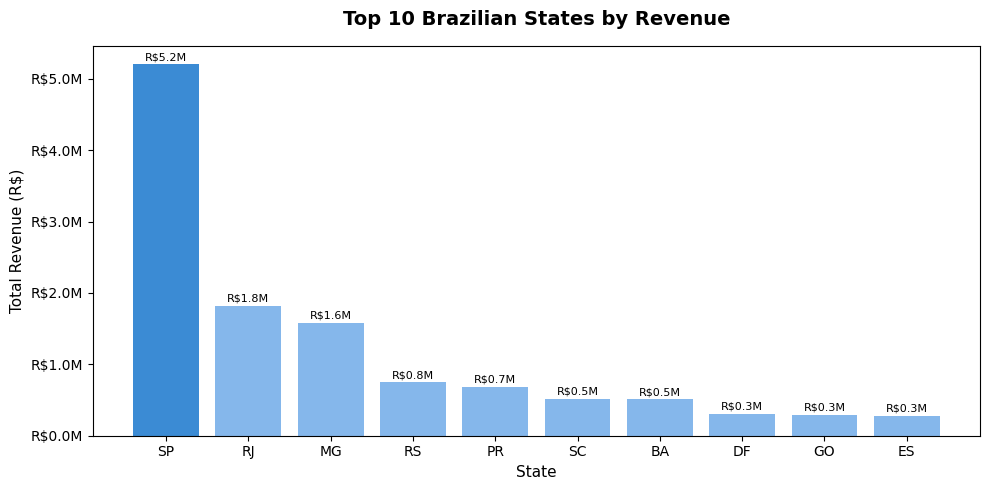

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#3B8BD4' if i == 0 else '#85B7EB' for i in range(len(df))]
bars = ax.bar(df['customer_state'], df['total_revenue'], color=colors)

ax.set_title('Top 10 Brazilian States by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Total Revenue (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

for bar, val in zip(bars, df['total_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
            f'R${val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('dashboards/revenue_by_state.png', dpi=150)
plt.show()
print("✅ Chart saved!")

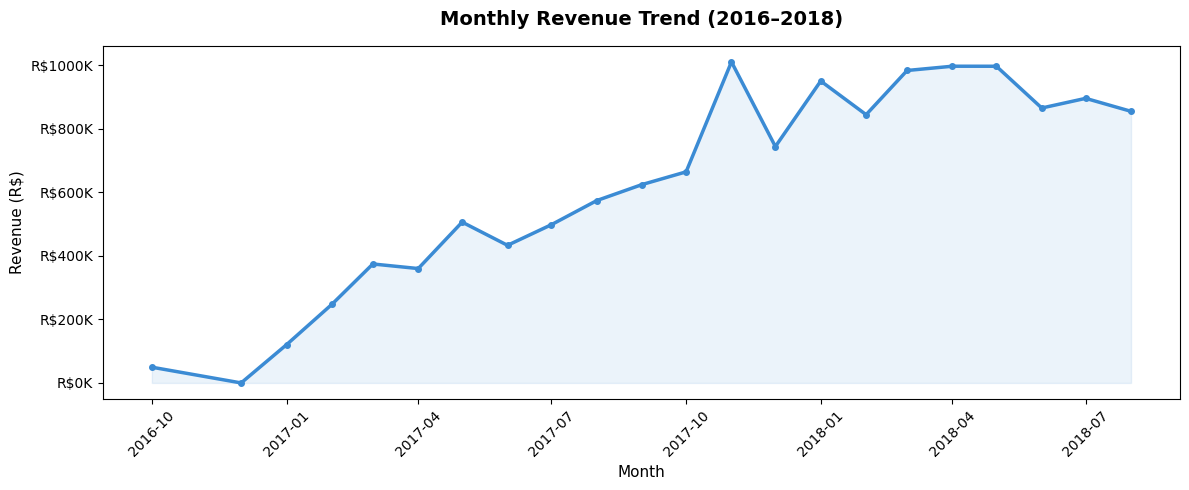

✅ Chart saved!


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

# Remove first and last rows (incomplete months)
df_plot = df_monthly.iloc[1:-1].copy()
df_plot['month'] = pd.to_datetime(df_plot['month'])

ax.plot(df_plot['month'], df_plot['monthly_revenue'],
        color='#3B8BD4', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(df_plot['month'], df_plot['monthly_revenue'],
                alpha=0.1, color='#3B8BD4')

ax.set_title('Monthly Revenue Trend (2016–2018)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dashboards/monthly_revenue_trend.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [7]:
# Advanced SQL — CTE to calculate Customer Lifetime Value
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        c.customer_state,
        COUNT(DISTINCT o.order_id) as total_orders,
        SUM(oi.price) as total_spent,
        MIN(o.order_purchase_timestamp) as first_order,
        MAX(o.order_purchase_timestamp) as last_order
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_unique_id, c.customer_state
)
SELECT
    customer_state,
    COUNT(customer_unique_id) as total_customers,
    ROUND(AVG(total_spent)::numeric, 2) as avg_clv,
    ROUND(AVG(total_orders)::numeric, 2) as avg_orders_per_customer,
    COUNT(CASE WHEN total_orders > 1 THEN 1 END) as repeat_customers,
    ROUND(COUNT(CASE WHEN total_orders > 1 THEN 1 END) * 100.0 / COUNT(*), 1) as repeat_rate_pct
FROM customer_orders
GROUP BY customer_state
ORDER BY avg_clv DESC
LIMIT 10;
"""
df_clv = pd.read_sql(query, engine)
print("Customer Lifetime Value by State:")
print(df_clv.to_string(index=False))

Customer Lifetime Value by State:
customer_state  total_customers  avg_clv  avg_orders_per_customer  repeat_customers  repeat_rate_pct
            PB              516   223.39                     1.03                12              2.3
            AC               77   207.57                     1.05                 4              5.2
            AL              399   201.29                     1.03                12              3.0
            AP               67   201.11                     1.01                 1              1.5
            RO              235   196.34                     1.05                 9              3.8
            PA              944   189.56                     1.03                24              2.5
            TO              272   182.43                     1.03                 7              2.6
            PI              481   180.69                     1.02                10              2.1
            MT              873   179.21                 

In [8]:
print("✅ Phase 3 SQL Analysis complete!")
print("Charts saved to dashboards/ folder")
print("Queries written: Window functions, CTEs, Revenue trends, CLV")


✅ Phase 3 SQL Analysis complete!
Charts saved to dashboards/ folder
Queries written: Window functions, CTEs, Revenue trends, CLV
